# Noise and Stochastic Runs

Real neural activity fluctuates. Spontaneous noise keeps a system off its fixed points and is
what makes resting-state dynamics interesting. In this tutorial you will:

1. attach a noise process to a model in **one line**,
2. compare a **deterministic** run with a **noisy** one,
3. run an **ensemble** of independent trials with `batch_size`, and
4. control reproducibility with **seeding** via {mod}`brainstate.random`.

brainmass ships several noise processes (see {doc}`/reference/noise`); we focus on the
{class}`~brainmass.OUProcess` (Ornstein–Uhlenbeck), a *colored* noise with a tunable
correlation time, and contrast it briefly with white noise.

:::{note}
Noise is part of the *model*: you pass a noise process when you build the `*Step` object
(e.g. `noise_x=`), and it is added automatically inside `update()`. The `Simulator` call is
unchanged — stochastic and deterministic runs look identical from the outside.
:::

In [1]:
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## What colored noise looks like

Before plugging it into a model, let us look at the noise itself. An
{class}`~brainmass.OUProcess` has a `sigma` (amplitude) and a `tau` (correlation time): the
larger `tau`, the **smoother** and more slowly-varying the signal. White noise
({class}`~brainmass.GaussianNoise`) has no memory at all. We sample each process step by step
with a tiny `Simulator` driving an identity-like update.

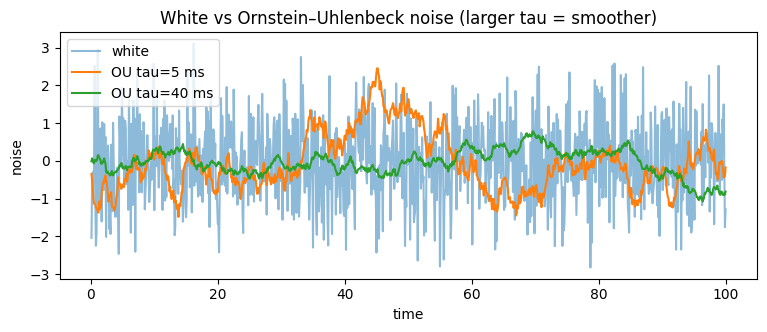

In [2]:
def sample_noise(proc, duration=100.0 * u.ms):
    """Run a stand-alone noise process and stack its per-step output.

    With ``monitors=None`` the Simulator records the return value of each
    ``proc.update()`` call (the freshly drawn sample), under the key 'output'.
    """
    sim = brainmass.Simulator(proc, dt=0.1 * u.ms)
    return sim.run(duration, monitors=None)

brainstate.random.seed(0)
ou_fast = sample_noise(brainmass.OUProcess(in_size=1, sigma=1.0, tau=5.0 * u.ms))
ou_slow = sample_noise(brainmass.OUProcess(in_size=1, sigma=1.0, tau=40.0 * u.ms))
white = sample_noise(brainmass.GaussianNoise(in_size=1, sigma=1.0))

fig, ax = plt.subplots(figsize=(9, 3.2))
brainmass.viz.plot_timeseries(white["output"], ts=white["ts"], labels=["white"], ax=ax, alpha=0.5)
brainmass.viz.plot_timeseries(ou_fast["output"], ts=ou_fast["ts"], labels=["OU tau=5 ms"], ax=ax)
brainmass.viz.plot_timeseries(ou_slow["output"], ts=ou_slow["ts"], labels=["OU tau=40 ms"], ax=ax)
ax.set_title("White vs Ornstein–Uhlenbeck noise (larger tau = smoother)")
ax.set_ylabel("noise");

## Deterministic vs noisy dynamics

Now we put the noise to work. We take a {class}`~brainmass.HopfStep` node *below* its
bifurcation (`a < 0`), so on its own it decays to rest — a silent, deterministic fixed point.
Attaching an OU process to its `x` component (`noise_x=`) makes the same node fluctuate
continuously around that rest state. This is the resting-state recipe in miniature: a stable
system kept alive by noise.

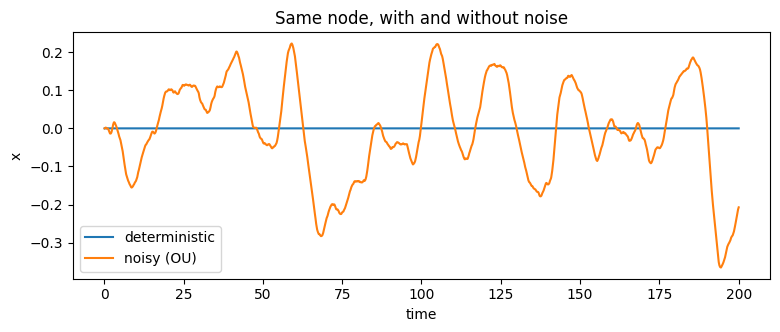

In [3]:
# Deterministic: a sub-critical Hopf node settles to rest.
det = brainmass.HopfStep(in_size=1, a=-0.05, w=0.3)
res_det = brainmass.Simulator(det, dt=0.1 * u.ms).run(200.0 * u.ms, monitors=["x"])

# Noisy: the SAME node, plus a one-line OU process on x.
brainstate.random.seed(1)
noisy = brainmass.HopfStep(
    in_size=1, a=-0.05, w=0.3,
    noise_x=brainmass.OUProcess(in_size=1, sigma=0.1, tau=20.0 * u.ms),
)
res_noisy = brainmass.Simulator(noisy, dt=0.1 * u.ms).run(200.0 * u.ms, monitors=["x"])

fig, ax = plt.subplots(figsize=(9, 3.2))
brainmass.viz.plot_timeseries(res_det["x"], ts=res_det["ts"], labels=["deterministic"], ax=ax)
brainmass.viz.plot_timeseries(res_noisy["x"], ts=res_noisy["ts"], labels=["noisy (OU)"], ax=ax)
ax.set_title("Same node, with and without noise")
ax.set_ylabel("x");

## An ensemble of trials with `batch_size`

Because each noisy run is one *realisation*, a single trajectory tells you little. To
characterise the dynamics you run many independent trials and look at the distribution. The
`Simulator` does this for free: pass `batch_size=N` and it initialises `N` independent copies
of the state and runs them in parallel (vectorised with `vmap` under the hood — no Python
loop). The output gains a leading **batch axis**.

Here we run 12 trials of the noise-driven node and plot them together with their mean.

ensemble shape (steps, batch, region): (2000, 12, 1)


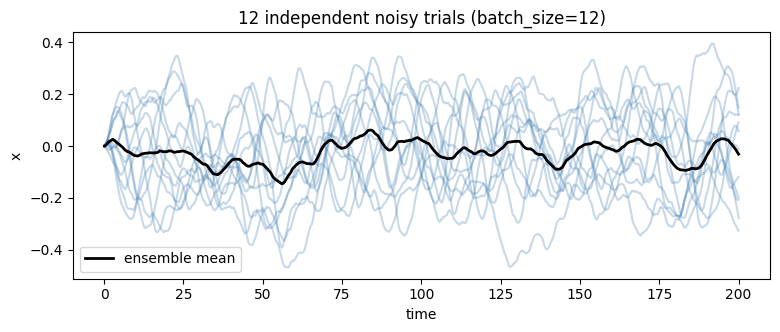

In [4]:
brainstate.random.seed(2)
ensemble_node = brainmass.HopfStep(
    in_size=1, a=-0.05, w=0.3,
    noise_x=brainmass.OUProcess(in_size=1, sigma=0.12, tau=20.0 * u.ms),
)
res_ens = brainmass.Simulator(ensemble_node, dt=0.1 * u.ms).run(
    200.0 * u.ms, monitors=["x"], batch_size=12
)
# shape is (steps, batch, region)
trials = np.asarray(res_ens["x"])[:, :, 0]        # (steps, batch); x is dimensionless
ts = np.asarray(u.get_magnitude(res_ens["ts"]))   # ts is unit-aware (ms) -> strip for plotting
print("ensemble shape (steps, batch, region):", res_ens["x"].shape)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(ts, trials, color="steelblue", alpha=0.3)
ax.plot(ts, trials.mean(axis=1), color="black", lw=2, label="ensemble mean")
ax.set_xlabel("time")
ax.set_ylabel("x")
ax.set_title("12 independent noisy trials (batch_size=12)")
ax.legend();

## Reproducibility: seeding

Stochastic results must be reproducible. brainmass draws its random numbers from
{mod}`brainstate.random`; calling `brainstate.random.seed(s)` before a run fixes the stream,
so the **same seed gives the same trajectory** and different seeds give different ones. Always
seed before a noisy run you intend to report.

In [5]:
def noisy_run(seed):
    brainstate.random.seed(seed)
    node = brainmass.HopfStep(
        in_size=1, a=-0.05, w=0.3,
        noise_x=brainmass.OUProcess(in_size=1, sigma=0.1, tau=20.0 * u.ms),
    )
    return brainmass.Simulator(node, dt=0.1 * u.ms).run(100.0 * u.ms, monitors=["x"])["x"]

a1 = noisy_run(7)
a2 = noisy_run(7)   # same seed
b = noisy_run(8)    # different seed

print("same seed -> identical trajectory: ", bool(jnp.allclose(a1, a2)))
print("different seed -> different trajectory:", not bool(jnp.allclose(a1, b)))

same seed -> identical trajectory:  True
different seed -> different trajectory: True


## What you learned

- Attach noise when you build a model (`noise_x=`, `noise_E=`, …); it is added inside
  `update()` and the `Simulator` call is unchanged.
- The {class}`~brainmass.OUProcess` is *colored* noise — `tau` sets its correlation time;
  {class}`~brainmass.GaussianNoise` is white.
- A sub-critical (silent) node becomes a fluctuating one when driven by noise — the
  resting-state recipe.
- `batch_size=N` runs an **ensemble** of independent trials in parallel; the output gains a
  batch axis.
- `brainstate.random.seed(s)` makes a stochastic run reproducible.

## Next steps

- {doc}`/tutorials/04_building_a_network` — couple many noisy regions into a whole-brain
  network.
- {doc}`/reference/noise` — the full set of noise processes (white, colored, Brownian, …).